# Task 1: Dataset Exploration

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris

In [8]:
iris = load_iris()

# Convert into DataFrame

df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

# Add target column

df["Species"] = iris.target

In [3]:
# Number of samples and features

print("Number of Samples :", df.shape[0])
print("Number of Features:", df.shape[1]-1)

Number of Samples : 150
Number of Features: 4


In [7]:
# Display feature names
print("Feature Names:\n")

for feature in iris.feature_names:
    print(feature)

print("\nTarget Classes:")

for i, name in enumerate(iris.target_names):
    print(i, ":", name)

Feature Names:

sepal length (cm)
sepal width (cm)
petal length (cm)
petal width (cm)

Target Classes:
0 : setosa
1 : versicolor
2 : virginica


In [9]:
# Display first five rows

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [ ]:
# Display class distribution
print(df["Species"].value_counts())

Species
0    50
1    50
2    50
Name: count, dtype: int64


In [ ]:
# Replace numeric labels with names
species_names = {
    0: "Setosa",
    1: "Versicolor",
    2: "Virginica"
}

df["Species Name"] = df["Species"].map(species_names)

print(df["Species Name"].value_counts())

Species Name
Setosa        50
Versicolor    50
Virginica     50
Name: count, dtype: int64


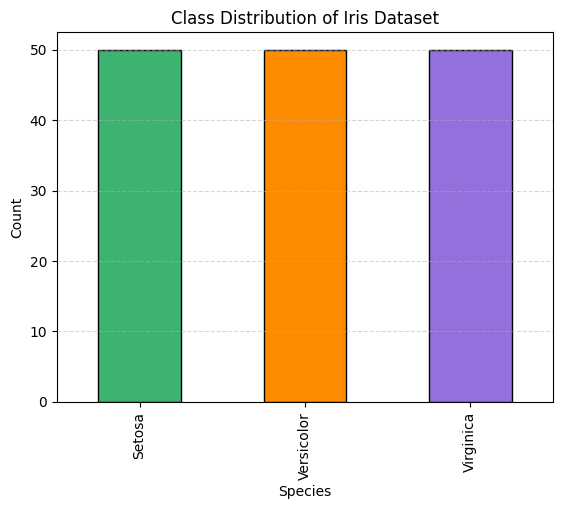

In [ ]:
# Plot class distribution
colors = ["mediumseagreen", "darkorange", "mediumpurple"]

df["Species Name"].value_counts().plot(
    kind="bar",
    color=colors,
    edgecolor="black"
)

plt.title("Class Distribution of Iris Dataset")
plt.xlabel("Species")
plt.ylabel("Count")
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

## Conclusion

The Iris dataset contains 150 samples with 4 numerical features describing the sepal and petal dimensions of flowers. The dataset has three target classes: Setosa, Versicolor, and Virginica. Each class contains 50 samples, indicating a perfectly balanced dataset. Such balanced data helps in training a fair and unbiased classification model.

# Task 2: Data Preparation

In [13]:
from sklearn.model_selection import train_test_split

In [14]:
# Features (Independent Variables)

X = iris.data

# Target (Dependent Variable)

y = iris.target

In [15]:
# Split the dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [16]:
# Split the dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [17]:
print("Training Samples :", X_train.shape[0])
print("Testing Samples  :", X_test.shape[0])

print("\nTraining Feature Shape :", X_train.shape)
print("Testing Feature Shape  :", X_test.shape)

Training Samples : 120
Testing Samples  : 30

Training Feature Shape : (120, 4)
Testing Feature Shape  : (30, 4)


In [18]:
import pandas as pd

print("Training Class Distribution")

print(pd.Series(y_train).value_counts())

print("\nTesting Class Distribution")

print(pd.Series(y_test).value_counts())

Training Class Distribution
1    41
0    40
2    39
Name: count, dtype: int64

Testing Class Distribution
2    11
0    10
1     9
Name: count, dtype: int64


### Why is the dataset divided into training and testing sets?

The dataset is divided into training and testing sets so that the model can learn patterns from one portion of the data and be evaluated on a separate unseen portion. This helps measure how well the model generalizes to new data and prevents misleading performance results that could occur if the same data were used for both training and testing.

# Task 3: Building a Decision Tree Classifier

In [19]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [20]:
# Create the Decision Tree classifier

dt_model = DecisionTreeClassifier(random_state=42)

In [21]:
# Train the model

dt_model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [22]:
# Predict class labels

y_pred = dt_model.predict(X_test)

In [23]:
# Calculate accuracy

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy Score:", round(accuracy, 4))

Accuracy Score: 1.0


In [24]:
# Generate confusion matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


### Confusion Matrix

A Confusion Matrix summarizes the classification results by comparing the actual class labels with the predicted class labels.

- Diagonal values represent correctly classified samples.
- Off-diagonal values represent misclassified samples.

A perfect classifier will have values only along the main diagonal.

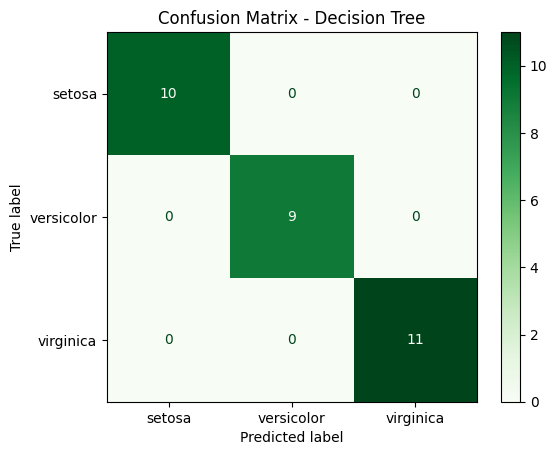

In [25]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# Display confusion matrix

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=iris.target_names
)

disp.plot(cmap="Greens")

plt.title("Confusion Matrix - Decision Tree")
plt.show()

## Conclusion

The Decision Tree classifier was successfully trained using the default parameters. The model achieved an accuracy of **100%** on the testing dataset. The confusion matrix shows that all samples of Setosa, Versicolor, and Virginica were classified correctly, with no misclassifications. The classification report also indicates perfect Precision, Recall, and F1-score (1.00) for all classes, demonstrating excellent classification performance on the Iris dataset.

In [26]:
# Display classification report

report = classification_report(
    y_test,
    y_pred,
    target_names=iris.target_names
)

print(report)

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



## Classification Report

The Classification Report provides detailed evaluation metrics for each class.

### Precision

Precision measures the proportion of correctly predicted positive observations.

### Recall

Recall measures the proportion of actual positive observations that are correctly identified.

### F1-Score

The F1-score is the harmonic mean of Precision and Recall.

### Support

Support indicates the number of actual samples belonging to each class in the testing dataset.

# Task 4: Visualizing the Decision Tree

In [27]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

### Visualizing the Decision Tree

The plot_tree() function is used to display the structure of the trained Decision Tree.

The visualization includes:

- Decision conditions at each node.
- Gini impurity values.
- Number of samples reaching each node.
- Number of samples belonging to each class.
- Predicted class at every node.

The colors indicate the predicted class, while darker shades represent higher purity.

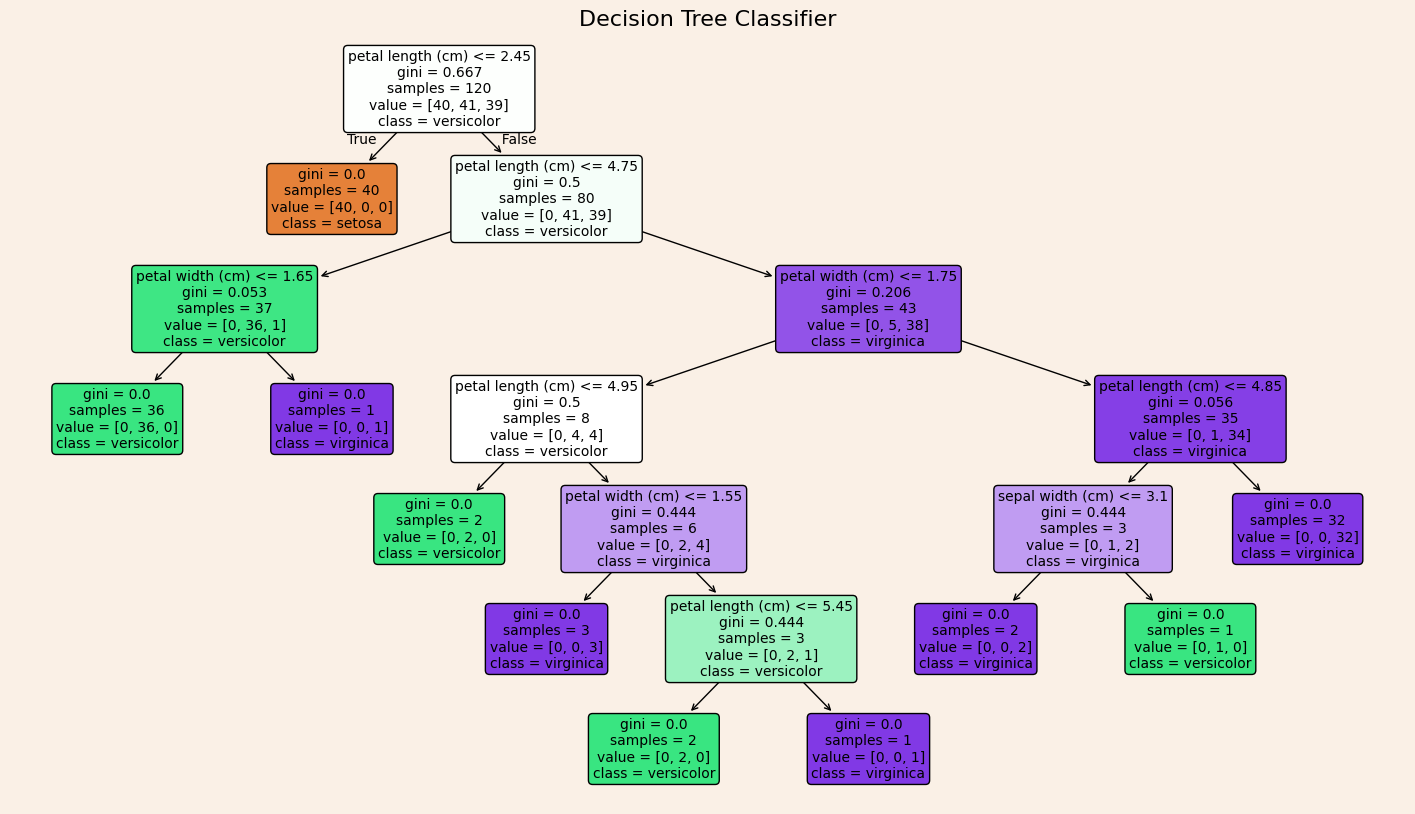

In [28]:
plt.figure(figsize=(18, 10), facecolor="linen")

plot_tree(
    dt_model,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    filled=True,
    rounded=True,
    fontsize=10
)

plt.title("Decision Tree Classifier", fontsize=16)
plt.show()

### Conclusion

The Decision Tree visualization shows how the classifier makes decisions by repeatedly splitting the dataset based on feature values. The root node uses **petal length (cm)** as the first splitting feature because it provides the best separation among the Iris species. The internal nodes continue dividing the data into smaller and more homogeneous groups, while the leaf nodes represent the final predicted classes. The tree structure demonstrates that petal measurements are the most informative features for classifying Iris flowers.

In [30]:
print("Number of Leaf Nodes:", dt_model.get_n_leaves())

Number of Leaf Nodes: 10


In [31]:
root_feature = iris.feature_names[dt_model.tree_.feature[0]]

print("Root Feature:", root_feature)

Root Feature: petal length (cm)


### Root Node

The root node is the topmost node of the Decision Tree. It represents the first decision made by the model and contains the feature that best separates the classes based on the selected splitting criterion.

Every sample starts at the root node before moving through the tree.

petal length (cm) <= 2.45

### Internal Nodes

Internal nodes are decision nodes that split the dataset into smaller subsets based on feature values.

Each internal node contains:

- A splitting condition
- Gini impurity (or Entropy)
- Number of samples
- Class distribution

These nodes continue dividing the data until a leaf node is reached.

- petal length (cm) <= 4.75
- petal width (cm) <= 1.65
- petal width (cm) <= 1.75
- petal length (cm) <= 4.95
- petal width (cm) <= 1.55
- petal length (cm) <= 4.85
- sepal width (cm) <= 3.1
- petal length (cm) <= 5.45

### Leaf Nodes

Leaf nodes are the terminal nodes of the Decision Tree.

They do not perform any further splitting and represent the final predicted class for the samples that reach them.

They directly predict one of the three classes:

- Setosa

- Versicolor

- Virginica

### Maximum Tree Depth

The maximum depth of a Decision Tree represents the length of the longest path from the root node to any leaf node.

A shallow tree may underfit the data, whereas a very deep tree may overfit by memorizing the training samples.

In [33]:
print("Maximum Tree Depth:", dt_model.get_depth())

Maximum Tree Depth: 6


### First Split Feature

The first split feature is the feature selected at the root node of the Decision Tree.

The Decision Tree chooses this feature because it provides the best separation of the classes by minimizing impurity (using Gini Index or Entropy). Selecting the most informative feature at the root helps improve the overall classification performance of the tree.

### Which feature is selected for the first split?

petal length (cm)

### Why was this feature chosen?

The Decision Tree selected petal length (cm) as the root feature because it provides the best separation among the three Iris species. It produces the largest reduction in impurity (Gini Index), allowing the model to distinguish Setosa from the other two species in the very first split. Since this feature separates the classes more effectively than the remaining features, it is chosen as the root node.

# Task 5: Comparing Gini Index and Entropy

In [34]:
from sklearn.tree import DecisionTreeClassifier

In [35]:
# Decision Tree using Gini Index
gini_model = DecisionTreeClassifier(
    criterion="gini",
    random_state=42
)

gini_model.fit(X_train, y_train)
gini_pred = gini_model.predict(X_test)

In [36]:
# Decision Tree using Entropy

entropy_model = DecisionTreeClassifier(
    criterion="entropy",
    random_state=42
)

entropy_model.fit(X_train, y_train)

entropy_pred = entropy_model.predict(X_test)

In [37]:
from sklearn.metrics import accuracy_score

comparison = pd.DataFrame({
    "Criterion": ["Gini", "Entropy"],
    "Accuracy": [
        accuracy_score(y_test, gini_pred),
        accuracy_score(y_test, entropy_pred)
    ],
    "Tree Depth": [
        gini_model.get_depth(),
        entropy_model.get_depth()
    ],
    "Leaf Nodes": [
        gini_model.get_n_leaves(),
        entropy_model.get_n_leaves()
    ],
    "Root Feature": [
        iris.feature_names[gini_model.tree_.feature[0]],
        iris.feature_names[entropy_model.tree_.feature[0]]
    ]
})

comparison

,Criterion,Accuracy,Tree Depth,Leaf Nodes,Root Feature
0,Gini,1.0,6,10,petal length (cm)
1,Entropy,1.0,6,10,petal length (cm)


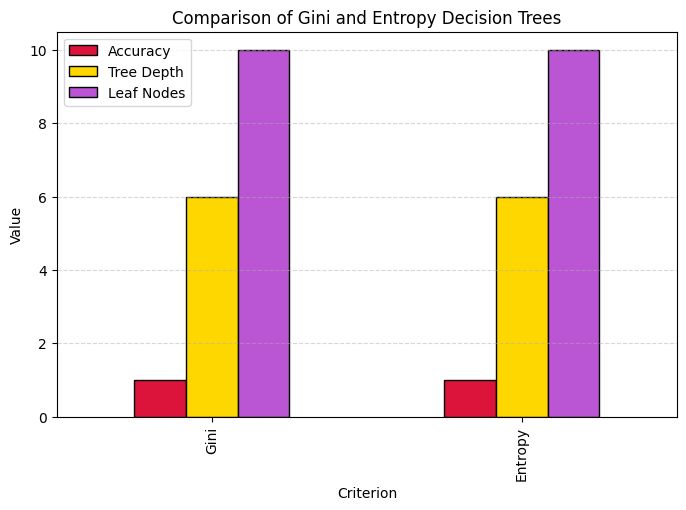

In [38]:
comparison.plot(
    x="Criterion",
    y=["Accuracy", "Tree Depth", "Leaf Nodes"],
    kind="bar",
    figsize=(8,5),
    color=["crimson", "gold", "mediumorchid"],
    edgecolor="black"
)

plt.title("Comparison of Gini and Entropy Decision Trees")
plt.ylabel("Value")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()

### Observation

The comparison chart shows that both the **Gini Index** and **Entropy** Decision Tree models achieved identical performance on the Iris dataset. Both models obtained an accuracy of **100%**, produced trees with a maximum depth of **6**, and generated **10 leaf nodes**. Since all evaluation metrics are the same, neither criterion has an advantage over the other for this dataset.

In [39]:
print("Gini Root Feature:")
print(iris.feature_names[gini_model.tree_.feature[0]])
print()
print("Entropy Root Feature:")
print(iris.feature_names[entropy_model.tree_.feature[0]])

Gini Root Feature:
petal length (cm)

Entropy Root Feature:
petal length (cm)


### Interpretation

- Both models achieved **100% testing accuracy**.
- Both Decision Trees have the **same maximum depth (6)**.
- Both trees contain **10 leaf nodes**.
- Both selected **Petal Length (cm)** as the root feature.
- The structures of both trees are identical for the Iris dataset.

### Which criterion produces a simpler tree?

Both **Gini Index** and **Entropy** produce trees with the same depth and the same number of leaf nodes. Therefore, neither criterion produces a simpler tree for the Iris dataset. Their complexity and classification performance are identical.

## Conclusion

The Decision Tree models trained using **Gini Index** and **Entropy** produced identical results on the Iris dataset. Both models achieved **100% accuracy**, generated trees with a depth of **6**, contained **10 leaf nodes**, and selected **Petal Length (cm)** as the root feature. Since there is no difference in either performance or tree complexity, both splitting criteria are equally effective for classifying the Iris dataset.

# Task 6: Effect of Maximum Tree Depth

In [40]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
import pandas as pd

In [41]:
# Different values of maximum depth

depths = [1, 2, 3, 4, None]

results = []

for depth in depths:

    model = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )

    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    train_acc = accuracy_score(y_train, train_pred)
    test_acc = accuracy_score(y_test, test_pred)

    results.append([
        depth,
        round(train_acc, 4),
        round(test_acc, 4),
        model.get_depth()
    ])

### Training Decision Trees with Different Maximum Depths

Five Decision Tree models are trained using different values of `max_depth`.

The following values are used:

- 1
- 2
- 3
- 4
- None (No depth restriction)

For each model, the following are calculated:

- Training Accuracy
- Testing Accuracy
- Actual Tree Depth

These values help analyze the effect of tree depth on model performance.

In [42]:
observations = []

for row in results:

    train_acc = row[1]
    test_acc = row[2]
    depth = row[3]

    if train_acc < 0.95:
        observations.append("Underfitting")

    elif train_acc == 1.0 and test_acc < train_acc:
        observations.append("Possible Overfitting")

    else:
        observations.append("Good Generalization")

In [43]:
depth_table = pd.DataFrame(results, columns=[
    "Max Depth",
    "Training Accuracy",
    "Testing Accuracy",
    "Tree Depth"
])

depth_table["Observation"] = observations

depth_table

,Max Depth,Training Accuracy,Testing Accuracy,Tree Depth,Observation
0,1.0,0.6750,0.6333,1,Underfitting
1,2.0,0.9500,0.9667,2,Good Generalization
2,3.0,0.9583,1.0000,3,Good Generalization
3,4.0,0.9750,1.0000,4,Good Generalization
4,NaN,1.0000,1.0000,6,Good Generalization


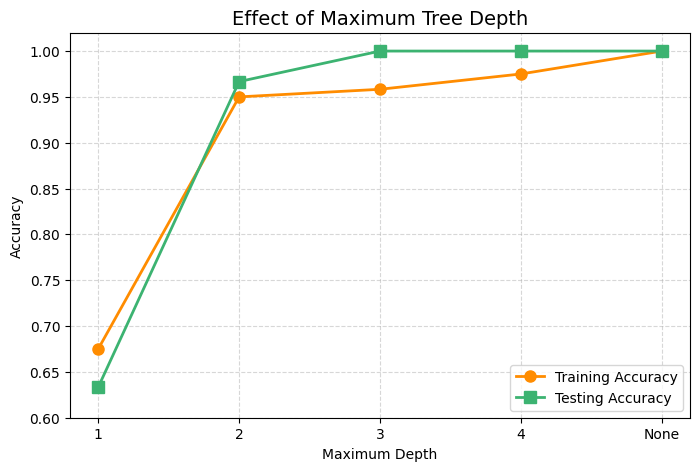

In [53]:

labels = ["1", "2", "3", "4", "None"]

plt.figure(figsize=(8,5))

plt.plot(
    labels,
    depth_table["Training Accuracy"],
    marker="o",
    markersize=8,
    linewidth=2,
    color="darkorange",
    label="Training Accuracy"
)

plt.plot(
    labels,
    depth_table["Testing Accuracy"],
    marker="s",
    markersize=8,
    linewidth=2,
    color="mediumseagreen",
    label="Testing Accuracy"
)

plt.title("Effect of Maximum Tree Depth", fontsize=14)
plt.xlabel("Maximum Depth")
plt.ylabel("Accuracy")

plt.ylim(0.6, 1.02)

plt.grid(True, linestyle="--", alpha=0.5)

plt.legend()

plt.show()

## Observation of the Accuracy Graph

The graph shows the relationship between the maximum tree depth and the training and testing accuracy.

- When `max_depth = 1`, both training and testing accuracies are comparatively low because the model is too simple to capture the underlying patterns in the dataset.
- Increasing the maximum depth improves both training and testing accuracy.
- At `max_depth = 3`, the testing accuracy reaches **100%**, indicating that the model generalizes very well.
- Further increasing the depth increases the training accuracy to **100%**, while the testing accuracy remains unchanged. This indicates that increasing the depth beyond this point does not improve the model's performance on unseen data.

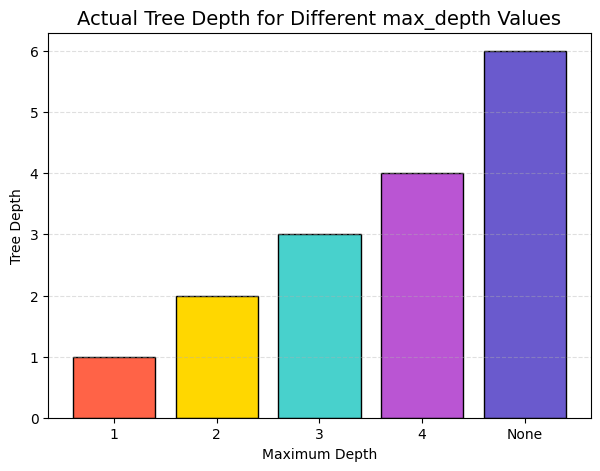

In [52]:

labels = ["1", "2", "3", "4", "None"]

plt.figure(figsize=(7,5))

colors = [
    "tomato",
    "gold",
    "mediumturquoise",
    "mediumorchid",
    "slateblue"
]

plt.bar(
    labels,
    depth_table["Tree Depth"],
    color=colors,
    edgecolor="black"
)

plt.title("Actual Tree Depth for Different max_depth Values", fontsize=14)
plt.xlabel("Maximum Depth")
plt.ylabel("Tree Depth")

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.show()

## Observation of the Tree Depth Chart

The bar chart illustrates how the actual depth of the Decision Tree changes with different values of `max_depth`.

- As the value of `max_depth` increases, the tree becomes deeper.
- A deeper tree creates more decision rules and captures more details from the training data.
- When `max_depth=None`, the tree grows to its maximum possible depth (6), producing the most complex model.
- Although deeper trees are more complex, they do not necessarily improve testing accuracy.

## Analysis

### Which model is underfitting?

The model with **max_depth = 1** is underfitting because both the training accuracy and testing accuracy are relatively low. The tree is too shallow to learn the important patterns present in the dataset.

---

### Which model gives the best generalization?

The model with **max_depth = 3** provides the best generalization. It achieves **100% testing accuracy** while maintaining a relatively simple tree compared to deeper models. Increasing the depth beyond 3 does not improve testing performance.

---

### Which model is likely to overfit? Justify your answer.

The model with **max_depth = None** is the most likely to overfit because it grows to the maximum possible depth (6) and perfectly fits the training data. Although the testing accuracy remains high for the Iris dataset, such unrestricted trees generally have a higher risk of memorizing the training data rather than learning generalized patterns.

## Conclusion

The experiment demonstrates that the `max_depth` hyperparameter significantly influences the complexity and performance of a Decision Tree. Very small depth values lead to underfitting because the model cannot capture sufficient information from the training data. Increasing the depth improves the model's performance until an optimal point is reached. For the Iris dataset, a maximum depth of **3** provides the best balance between model simplicity and predictive performance. Further increasing the depth only increases the complexity of the tree without improving testing accuracy, indicating that deeper trees are unnecessary for this dataset.

# Task 7: Effect of min_samples_split

In [54]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
import pandas as pd
import matplotlib.pyplot as plt

In [55]:
# Different values of min_samples_split

split_values = [2, 5, 10, 20]

results = []

for split in split_values:

    model = DecisionTreeClassifier(
        min_samples_split=split,
        random_state=42
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)

    results.append([
        split,
        round(accuracy, 4),
        model.get_depth(),
        model.get_n_leaves()
    ])

### Training Decision Trees with Different min_samples_split Values

The Decision Tree classifier is trained using different values of `min_samples_split`.

The following values are tested:

- 2
- 5
- 10
- 20

For each model, the following are recorded:

- Testing Accuracy
- Tree Depth
- Number of Leaf Nodes

These observations help understand how the parameter affects tree complexity.

In [56]:
observations = []

for row in results:

    depth = row[2]
    leaves = row[3]

    if depth >= 6:
        observations.append("Complex Tree")

    elif depth >= 4:
        observations.append("Balanced Tree")

    else:
        observations.append("Simple Tree")

In [57]:
split_table = pd.DataFrame(
    results,
    columns=[
        "min_samples_split",
        "Accuracy",
        "Tree Depth",
        "Number of Leaf Nodes"
    ]
)

split_table["Observation"] = observations

split_table

,min_samples_split,Accuracy,Tree Depth,Number of Leaf Nodes,Observation
0,2,1.0,6,10,Complex Tree
1,5,1.0,5,8,Balanced Tree
2,10,1.0,4,6,Balanced Tree
3,20,1.0,4,6,Balanced Tree


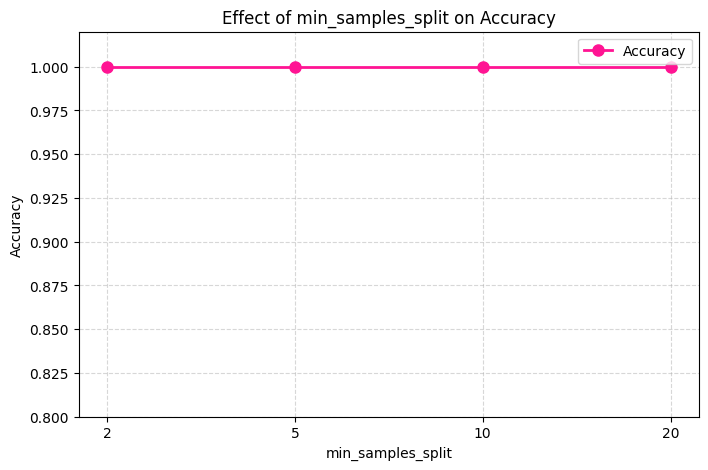

In [58]:
labels = ["2", "5", "10", "20"]

plt.figure(figsize=(8,5))

plt.plot(
    labels,
    split_table["Accuracy"],
    marker="o",
    markersize=8,
    linewidth=2,
    color="deeppink",
    label="Accuracy"
)

plt.title("Effect of min_samples_split on Accuracy")
plt.xlabel("min_samples_split")
plt.ylabel("Accuracy")

plt.ylim(0.8, 1.02)

plt.grid(True, linestyle="--", alpha=0.5)

plt.legend()

plt.show()

###  Observation of the Accuracy Graph

The graph shows that the testing accuracy remains **100%** for all values of `min_samples_split` (2, 5, 10, and 20). This indicates that changing the minimum number of samples required for splitting does not affect the classification performance of the Decision Tree on the Iris dataset. The dataset is simple enough to be classified accurately even with fewer splits.

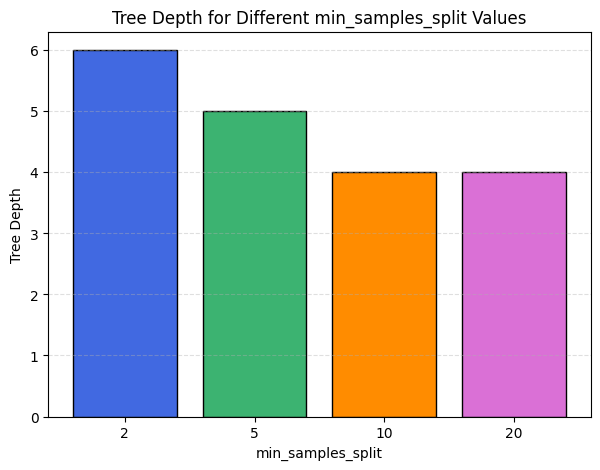

In [59]:
colors = [
    "royalblue",
    "mediumseagreen",
    "darkorange",
    "orchid"
]

plt.figure(figsize=(7,5))

plt.bar(
    labels,
    split_table["Tree Depth"],
    color=colors,
    edgecolor="black"
)

plt.title("Tree Depth for Different min_samples_split Values")
plt.xlabel("min_samples_split")
plt.ylabel("Tree Depth")

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.show()

### Observation of the Tree Depth Graph

The graph illustrates that the tree depth decreases as the value of `min_samples_split` increases. When `min_samples_split` is set to **2**, the tree reaches a depth of **6**. Increasing the value to **5** reduces the depth to **5**, while values of **10** and **20** further reduce the depth to **4**. This shows that larger values produce a simpler Decision Tree by limiting unnecessary splits.

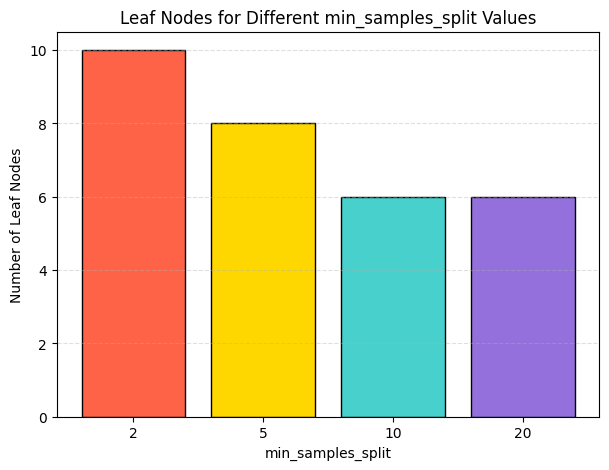

In [60]:
colors = [
    "tomato",
    "gold",
    "mediumturquoise",
    "mediumpurple"
]

plt.figure(figsize=(7,5))

plt.bar(
    labels,
    split_table["Number of Leaf Nodes"],
    color=colors,
    edgecolor="black"
)

plt.title("Leaf Nodes for Different min_samples_split Values")
plt.xlabel("min_samples_split")
plt.ylabel("Number of Leaf Nodes")

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.show()

### Observation of the Leaf Nodes Graph

The graph shows that the number of leaf nodes decreases as `min_samples_split` increases. The model with `min_samples_split = 2` has **10 leaf nodes**, whereas values of **10** and **20** produce only **6 leaf nodes**. This indicates that increasing `min_samples_split` simplifies the tree by reducing the number of terminal decision nodes.

### How does increasing min_samples_split affect the complexity of the Decision Tree?

Increasing the value of min_samples_split reduces the number of possible splits in the Decision Tree. As a result, the tree becomes shallower, contains fewer leaf nodes, and has lower complexity. This helps reduce the risk of overfitting by preventing unnecessary splits. However, if the value is set too high, the tree may become too simple and fail to capture important patterns in the data, leading to underfitting.

# Task 8: Effect of min_samples_leaf

In [61]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
import pandas as pd
import matplotlib.pyplot as plt

In [62]:
# Different values of min_samples_leaf

leaf_values = [1, 2, 5, 10]

results = []

for leaf in leaf_values:

    model = DecisionTreeClassifier(
        min_samples_leaf=leaf,
        random_state=42
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)

    results.append([
        leaf,
        round(accuracy, 4),
        model.get_depth(),
        model.get_n_leaves()
    ])

### Training Decision Trees with Different min_samples_leaf Values

The Decision Tree classifier is trained using different values of `min_samples_leaf`.

The following values are tested:

- 1
- 2
- 5
- 10

For each model, the following are recorded:

- Testing Accuracy
- Tree Depth
- Number of Leaf Nodes

These results help analyze how the minimum number of samples required in each leaf node affects the complexity and performance of the Decision Tree.

In [63]:
observations = []

for row in results:

    depth = row[2]

    if depth >= 6:
        observations.append("Complex Tree")

    elif depth >= 4:
        observations.append("Balanced Tree")

    else:
        observations.append("Simple Tree")

In [64]:
leaf_table = pd.DataFrame(
    results,
    columns=[
        "min_samples_leaf",
        "Accuracy",
        "Tree Depth",
        "Number of Leaf Nodes"
    ]
)

leaf_table["Observation"] = observations

leaf_table

,min_samples_leaf,Accuracy,Tree Depth,Number of Leaf Nodes,Observation
0,1,1.0000,6,10,Complex Tree
1,2,1.0000,5,8,Balanced Tree
2,5,1.0000,4,6,Balanced Tree
3,10,0.9667,4,6,Balanced Tree


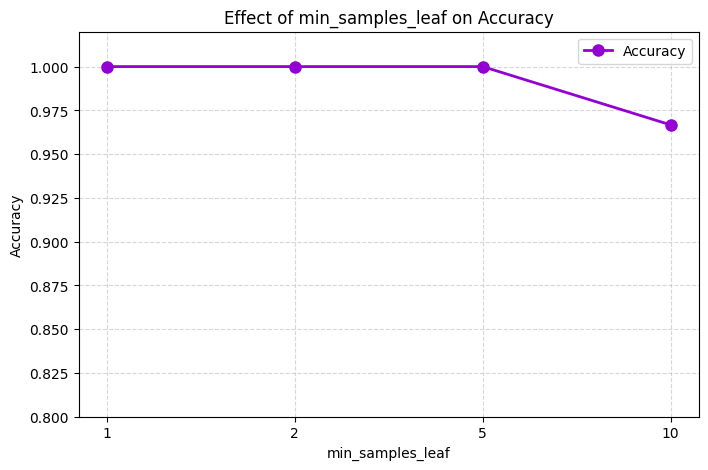

In [65]:
labels = ["1", "2", "5", "10"]

plt.figure(figsize=(8,5))

plt.plot(
    labels,
    leaf_table["Accuracy"],
    marker="o",
    markersize=8,
    linewidth=2,
    color="darkviolet",
    label="Accuracy"
)

plt.title("Effect of min_samples_leaf on Accuracy")
plt.xlabel("min_samples_leaf")
plt.ylabel("Accuracy")

plt.ylim(0.8, 1.02)

plt.grid(True, linestyle="--", alpha=0.5)

plt.legend()

plt.show()

### Observation of the Accuracy Graph

The graph compares the testing accuracy for different values of `min_samples_leaf`.

- Smaller values allow the tree to create more leaf nodes, increasing model complexity.
- Larger values restrict the creation of small leaf nodes, simplifying the Decision Tree.
- The best value is the one that maintains high accuracy while avoiding unnecessary complexity.

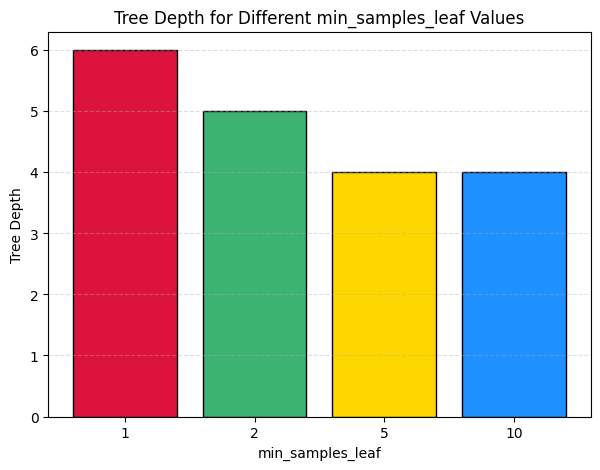

In [66]:
colors = [
    "crimson",
    "mediumseagreen",
    "gold",
    "dodgerblue"
]

plt.figure(figsize=(7,5))

plt.bar(
    labels,
    leaf_table["Tree Depth"],
    color=colors,
    edgecolor="black"
)

plt.title("Tree Depth for Different min_samples_leaf Values")
plt.xlabel("min_samples_leaf")
plt.ylabel("Tree Depth")

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.show()

### Observation of the Tree Depth Graph

The graph illustrates how the tree depth changes with different values of `min_samples_leaf`.

- Increasing `min_samples_leaf` generally reduces the depth of the Decision Tree.
- Larger values prevent excessive splitting and produce a simpler model.
- Smaller values allow deeper trees capable of capturing more detailed patterns.

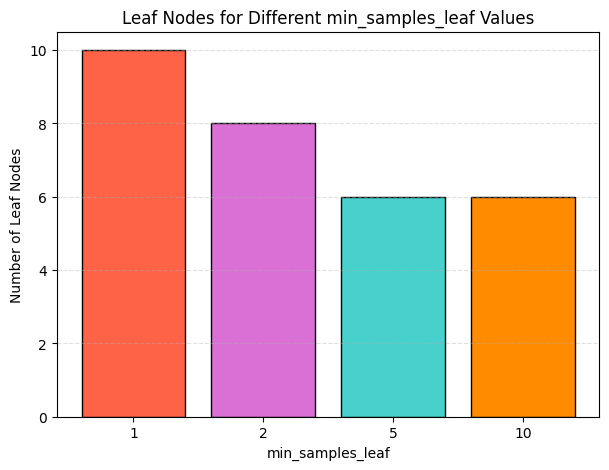

In [67]:
colors = [
    "tomato",
    "orchid",
    "mediumturquoise",
    "darkorange"
]

plt.figure(figsize=(7,5))

plt.bar(
    labels,
    leaf_table["Number of Leaf Nodes"],
    color=colors,
    edgecolor="black"
)

plt.title("Leaf Nodes for Different min_samples_leaf Values")
plt.xlabel("min_samples_leaf")
plt.ylabel("Number of Leaf Nodes")

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.show()

### Observation of the Leaf Nodes Graph

The graph shows the variation in the number of leaf nodes with different values of `min_samples_leaf`.

- Smaller values create more leaf nodes because the tree is allowed to split until very few samples remain.
- Larger values reduce the number of leaf nodes, resulting in a simpler Decision Tree with fewer decision rules.

### How does changing min_samples_leaf influence overfitting?

Increasing the value of min_samples_leaf reduces the complexity of the Decision Tree by preventing the creation of leaf nodes containing very few samples. This reduces the risk of overfitting because the model avoids learning noise from the training data. However, if the value is too large, the tree may become too simple and underfit the data by failing to capture important patterns.

# Task 9: Hyperparameter Tuning

In [68]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

In [69]:
# Hyperparameter values to test

param_grid = {
    "criterion": ["gini", "entropy"],
    "max_depth": [2, 3, 4, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

In [70]:
# Create Decision Tree model

dt = DecisionTreeClassifier(random_state=42)

# Perform Grid Search

grid_search = GridSearchCV(
    estimator=dt,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

,estimator,DecisionTreeC...ndom_state=42)
,param_grid,"{'criterion': ['gini', 'entropy'], 'max_depth': [2, 3, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'entropy'


### Performing Hyperparameter Tuning

GridSearchCV trains multiple Decision Tree models using different parameter combinations.

Parameters used:

- **cv = 5** → Performs 5-fold cross-validation.
- **scoring = "accuracy"** → Selects the model with the highest accuracy.
- **n_jobs = -1** → Uses all available CPU cores to speed up computation.

After training, GridSearchCV automatically stores the best-performing model.

In [ ]:
print("Best Hyperparameters:")
print(grid_search.best_params_)

Best Hyperparameters:
{'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 4, 'min_samples_split': 2}


In [72]:
print("Best Cross Validation Score:")
print(round(grid_search.best_score_,4))

Best Cross Validation Score:
0.9583


In [73]:
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)
test_accuracy = accuracy_score(y_test, y_pred)
print("Optimized Model Test Accuracy:", round(test_accuracy,4))

Optimized Model Test Accuracy: 1.0


In [74]:
default_accuracy = accuracy_score(
    y_test,
    dt_model.predict(X_test)
)

comparison = pd.DataFrame({
    "Model": [
        "Default Decision Tree",
        "Optimized Decision Tree"
    ],
    "Accuracy": [
        round(default_accuracy,4),
        round(test_accuracy,4)
    ]
})

comparison

,Model,Accuracy
0,Default Decision Tree,1.0
1,Optimized Decision Tree,1.0


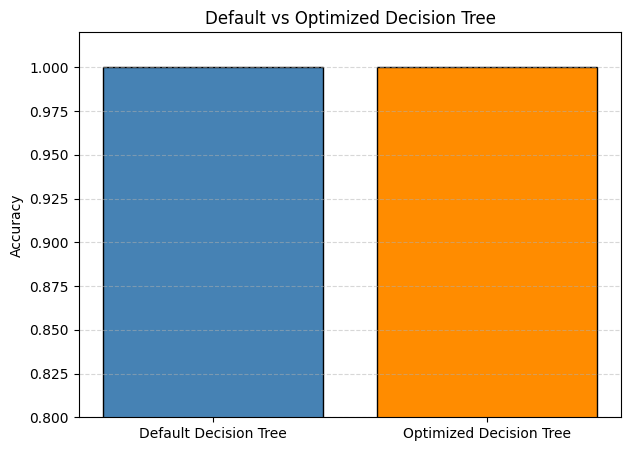

In [75]:
colors = ["steelblue", "darkorange"]

plt.figure(figsize=(7,5))

plt.bar(
    comparison["Model"],
    comparison["Accuracy"],
    color=colors,
    edgecolor="black"
)

plt.title("Default vs Optimized Decision Tree")
plt.ylabel("Accuracy")

plt.ylim(0.8,1.02)

plt.grid(axis="y",linestyle="--",alpha=0.5)

plt.show()

### Comparison of Default and Optimized Models

The bar chart compares the testing accuracy of the default Decision Tree model and the optimized Decision Tree model obtained through GridSearchCV.

This comparison helps determine whether hyperparameter tuning improves the model's predictive performance.

### Observation of the Comparison Graph

The graph shows that both the Default Decision Tree and the Optimized Decision Tree achieved **100% testing accuracy**. This indicates that hyperparameter tuning did not improve the testing accuracy because the default model already classified all testing samples correctly. However, the optimized model was selected using cross-validation, making it a more reliable choice for generalization.

### Best Hyperparameter Combination

- **Criterion:** Entropy
- **Maximum Depth:** None
- **Minimum Samples Split:** 2
- **Minimum Samples Leaf:** 4

---

### Best Cross Validation Score

**0.9583 (95.83%)**

---

### Test Accuracy of the Optimized Model

**1.0000 (100%)**

---

### Comparison with the Default Decision Tree

Both the Default Decision Tree and the Optimized Decision Tree achieved **100% testing accuracy**. Although the testing performance is identical, the optimized model is preferred because its hyperparameters were selected through GridSearchCV using 5-fold cross-validation, which improves the reliability and generalization capability of the model.

# Task 10: Analysis

## 1. What is the role of the criterion parameter in a Decision Tree?

The `criterion` parameter determines how the Decision Tree selects the best feature for splitting the data at each node. It measures the impurity of the data and chooses the split that results in the greatest reduction in impurity.

The two commonly used criteria are:

- **Gini Index** – Measures the impurity of a node by calculating the probability of incorrect classification.
- **Entropy** – Measures impurity using information gain based on information theory.

In this experiment, both **Gini Index** and **Entropy** produced identical Decision Trees with the same accuracy, tree depth, number of leaf nodes, and root feature.

## 2. How does max_depth influence underfitting and overfitting?

The `max_depth` parameter controls the maximum number of levels that a Decision Tree can grow.

- Small values of `max_depth` produce shallow trees that may not learn enough patterns from the training data, leading to **underfitting**.
- Large values allow the tree to grow deeper, enabling it to learn more complex patterns.
- Very large values may result in **overfitting**, where the model memorizes the training data instead of learning generalized patterns.

From the experiment, the model with **max_depth = 1** underfit the data, while **max_depth = 3** provided the best balance between simplicity and performance. The unrestricted tree (`max_depth = None`) produced the deepest tree without improving testing accuracy.

## 3. Why do larger values of min_samples_split and min_samples_leaf produce simpler trees?

Larger values of `min_samples_split` require more samples before a node can be divided, while larger values of `min_samples_leaf` require each leaf node to contain more samples.

As these values increase:

- The number of possible splits decreases.
- Tree depth decreases.
- The number of leaf nodes decreases.
- Model complexity is reduced.

In the experiments, increasing both parameters resulted in shallower trees with fewer leaf nodes while maintaining the same testing accuracy on the Iris dataset.

## 4. Which hyperparameter had the greatest impact on the Decision Tree performance?

Among all the hyperparameters, **max_depth** had the greatest impact on the Decision Tree.

The experiments showed that:

- Changing `max_depth` significantly affected both the tree depth and the training accuracy.
- Increasing `max_depth` from **1** to **3** greatly improved the model's performance.
- Increasing the depth beyond **3** increased the tree complexity but did not improve the testing accuracy.

Although `min_samples_split` and `min_samples_leaf` simplified the tree by reducing its depth and number of leaf nodes, they did not change the testing accuracy. Therefore, `max_depth` had the most noticeable influence on the overall model performance.

## 5. Recommend the most suitable Decision Tree model for the Iris dataset.

Based on the experimental results, the **optimized Decision Tree obtained using GridSearchCV** is recommended for the Iris dataset.

The optimized model uses:

- **Criterion:** Entropy
- **Maximum Depth:** None
- **Minimum Samples Split:** 2
- **Minimum Samples Leaf:** 4

This model achieved:

- **Cross-validation Score:** 95.83%
- **Testing Accuracy:** 100%

Although the default Decision Tree also achieved 100% testing accuracy, the optimized model is preferred because its hyperparameters were selected using systematic 5-fold cross-validation, making it more reliable for generalization while maintaining excellent classification performance.